# Simulate 100 Non-Overlapping Truncated Nanocubes in a TEM Image

This notebook is adapted from the collaborator's **3D phantom → rotation → line-integral projection → multi-particle TEM scene** workflow.

## Requested configuration

- **100** cube nanoparticles
- **90** particles with exactly the same orientation
- **10** particles with varied orientations
- **No overlap** between particle masks
- **5–10% corner truncation**, controlled by `TRUNCATION_RANGE`
- TEM-like bright-field contrast, background texture, blur, and noise
- COCO annotations, instance masks, metadata, and explanatory visualizations

## Main tuning parameters

```python
N_PARTICLES = 100
N_ALIGNED = 90
TRUNCATION_RANGE = (0.05, 0.10)
ALIGNED_INPLANE_DEG = 0.0
RANDOM_MAX_TILT_DEG = 10.0
SIZE_RANGE_PX = (56, 72)
CANVAS_SIZE = 1200
```

`truncation_fraction = 0.08` means that **8% of the full cube edge length is removed at each corner along the adjacent edges**.


In [1]:
# Install the packages used by the simulator.
# Google Colab already includes most of them, but this cell makes the notebook reproducible.
!pip -q install numpy scipy scikit-image pandas matplotlib


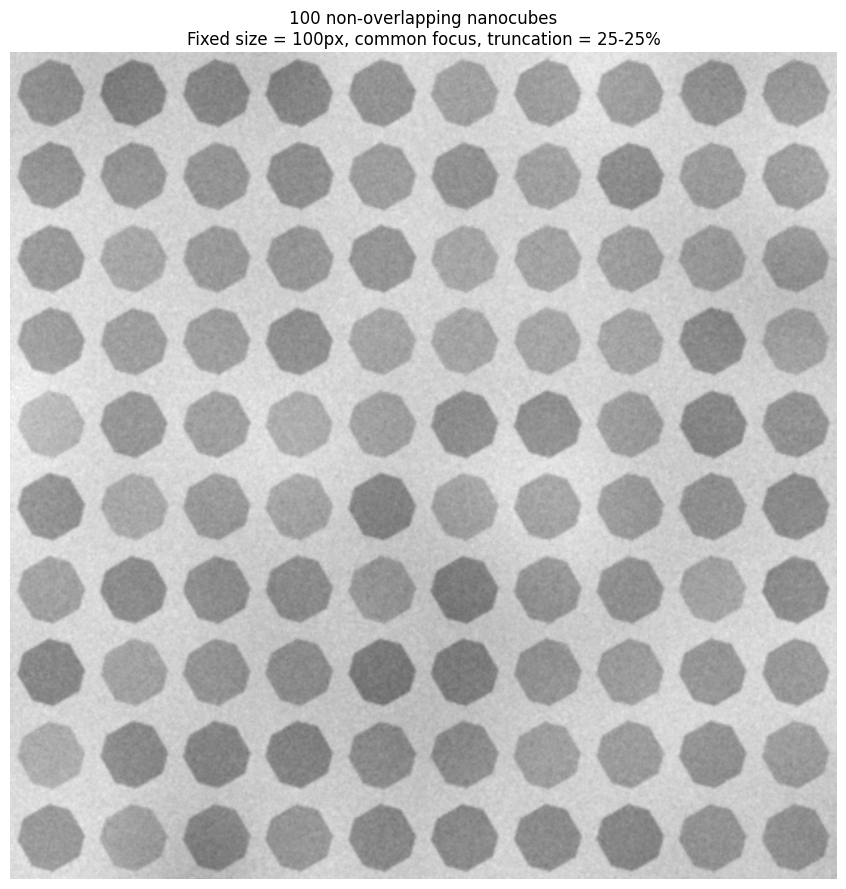

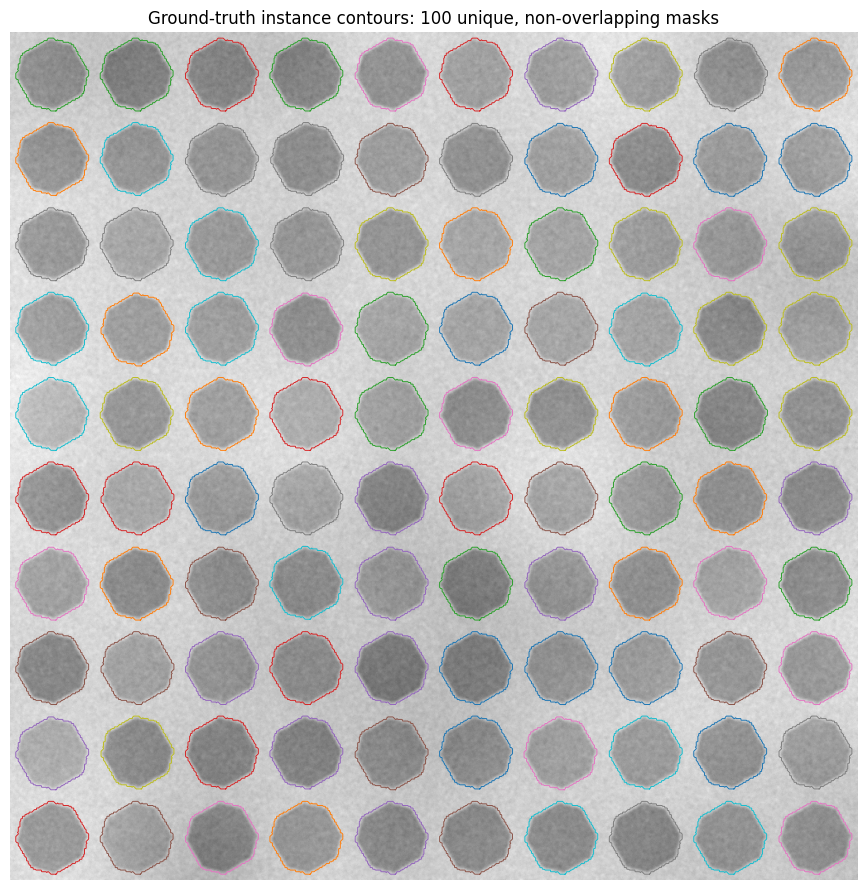

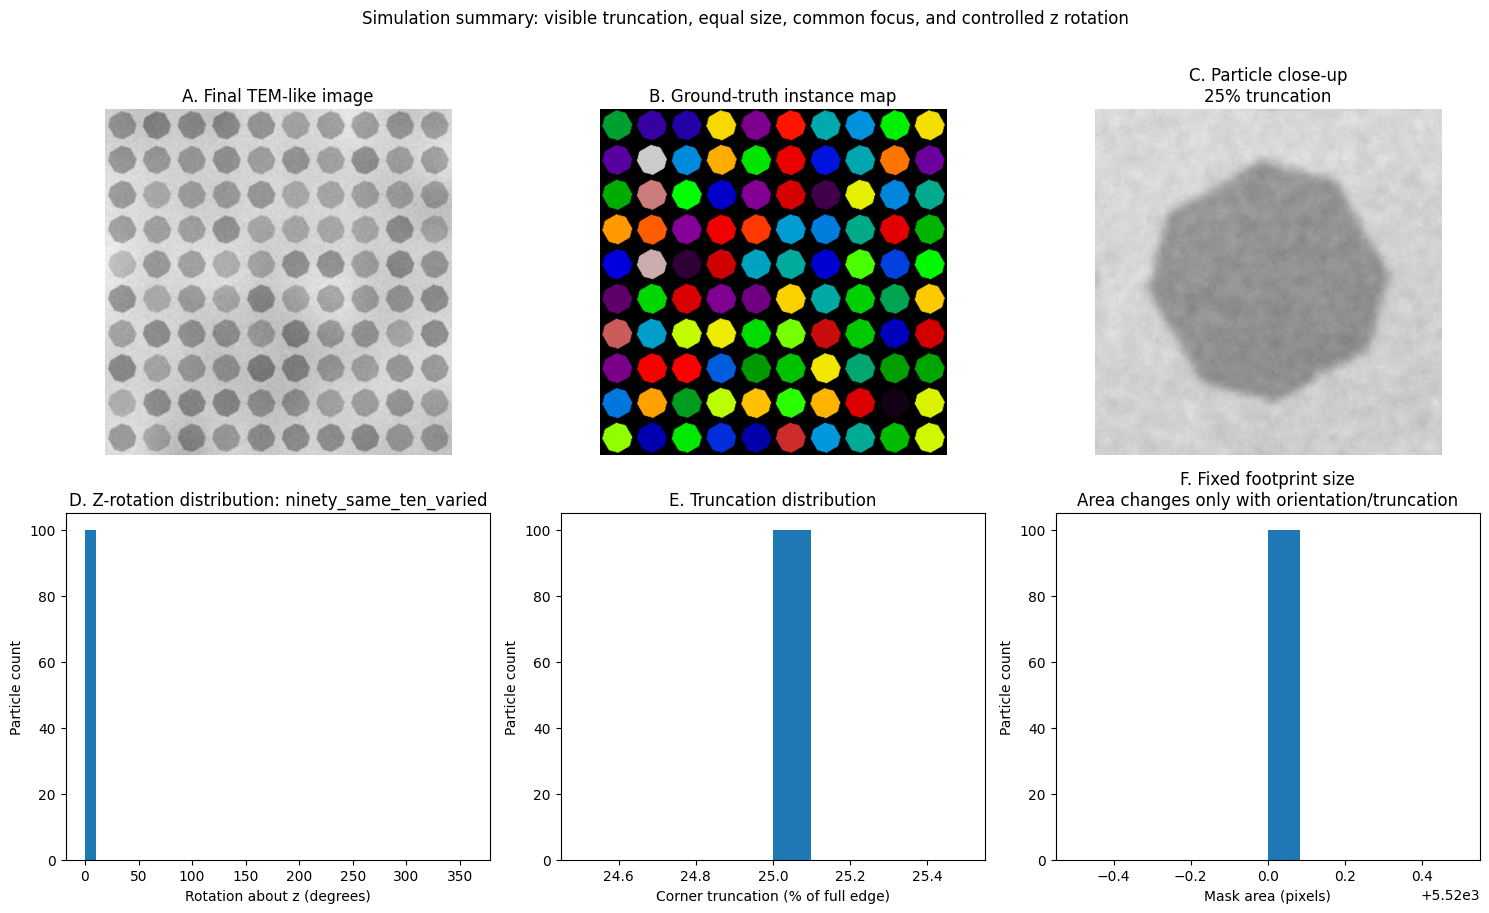

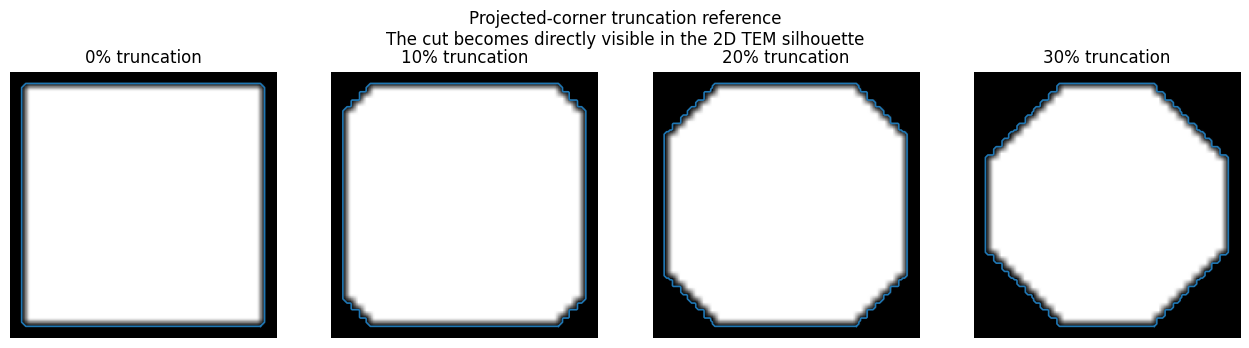


Saved files
-----------
  cube_scene_v2_tem.png
  cube_scene_v2_instances.png
  cube_scene_v2_explanation.png
  cube_scene_v2_truncation_reference.png
  cube_scene_v2_raw.npy
  cube_scene_v2_masks.npz
  cube_scene_v2_metadata.csv
  cube_scene_v2_coco.json
  cube_scene_v2_outputs.zip

Validation summary
------------------
Particle count: 100
Unique particle sizes: [np.int64(100)]
Truncation range: 25.0% to 25.0%
Orientation mode: ninety_same_ten_varied
Per-particle defocus variation: none
Pixel-level overlap: 0 (checked during placement)
    id orientation_group  z_rotation_deg  tilt_x_deg  tilt_y_deg  \
0    1           aligned             0.0        30.0         0.0   
1    2           aligned             0.0        30.0         0.0   
2    3           aligned             0.0        30.0         0.0   
3    4           aligned             0.0        30.0         0.0   
4    5           aligned             0.0        30.0         0.0   
5    6           aligned             0.0        

In [15]:

"""
Colab-ready simulator for 100 non-overlapping truncated nanocubes.

Key corrections in version 2
----------------------------
1. Visible corner truncation:
   A strict 3D vertex cut can remain almost invisible in a face-on TEM
   projection because material still exists along the beam direction.
   The default "projected_octagon" geometry cuts the four vertical cube
   edges, so the projected 2D outline is visibly truncated.

2. Equal particle size:
   Every particle is resized to exactly PARTICLE_SIZE_PX.

3. Equal focus and contrast:
   No particle-specific defocus is applied. One common blur is applied to
   the complete image, and particle-to-particle intensity variation is off
   by default.

4. Configurable rotation about the z axis:
   ORIENTATION_MODE controls whether 90 particles are aligned and 10 vary,
   or whether all particles rotate approximately around one common z angle.

Outputs
-------
cube_scene_v2_tem.png
cube_scene_v2_instances.png
cube_scene_v2_explanation.png
cube_scene_v2_truncation_reference.png
cube_scene_v2_raw.npy
cube_scene_v2_masks.npz
cube_scene_v2_metadata.csv
cube_scene_v2_coco.json
cube_scene_v2_outputs.zip
"""

from __future__ import annotations

# ============================================================
# ALL USER-TUNABLE PARAMETERS
# Edit only this section for routine experiments.
# ============================================================

# ---------- Reproducibility ----------
SEED = 7

# ---------- Particle count ----------
N_PARTICLES = 100
N_ALIGNED = 100  # Used only by "ninety_same_ten_varied"

# ---------- Canvas and spacing ----------
CANVAS_SIZE = 1024
PARTICLE_SIZE_PX = 100       # Every particle has exactly this projected size
MIN_GAP_PX = 1              # Minimum empty space between particle masks

# ---------- 3D phantom resolution ----------
PHANTOM_VOXELS = 72         # Higher = smoother corners, but slower

# ---------- Corner truncation ----------
# "projected_octagon":
#   Produces visibly truncated corners in a face-on TEM projection.
#
# "true_3d_vertices":
#   Cuts only the eight 3D cube vertices. In a face-on projection, the
#   silhouette can still look almost square, even at a large truncation.
#
# "combined":
#   Applies both the projected-outline cut and the true 3D vertex cut.
TRUNCATION_GEOMETRY = "projected_octagon"

# Fraction of the full cube edge removed at each projected corner.
# Examples:
#   (0.05, 0.10) -> random 5-10% truncation
#   (0.20, 0.20) -> fixed 20% truncation
TRUNCATION_RANGE = (0.25, 0.25)
TRUNCATION_STEP = 0.01

# ---------- Orientation about the electron-beam z axis ----------
# Available modes:
#   "ninety_same_ten_varied":
#       The first N_ALIGNED particles share the common z angle.
#       The remaining particles use random z angles.
#
#   "all_common_z":
#       All particles are approximately rotated by COMMON_Z_ROTATION_DEG,
#       with optional small jitter.
#
#   "all_random_z":
#       Every particle receives a random z angle.
ORIENTATION_MODE = "ninety_same_ten_varied"

# Common in-plane rotation about z.


# Small orientation spread around the common z angle.
# Set to 0.0 for exactly the same direction.
COMMON_Z_JITTER_DEG = 0.0

# Z-angle range for the varied particles or for "all_random_z".
RANDOM_Z_ROTATION_RANGE_DEG = (0.0, 360.0)

# Optional x/y tilts. Keep disabled to preserve the same face-on appearance
# and avoid apparent size or thickness differences.
ALLOW_XY_TILT = True
COMMON_TILT_X_DEG = 30
COMMON_TILT_Y_DEG = 0.0
COMMON_Z_ROTATION_DEG = 0.0
RANDOM_MAX_XY_TILT_DEG = 0.0

# ---------- Particle consistency ----------
# Keep these at zero when all particles should have the same apparent
# size, contrast, and shape quality.
INTENSITY_VARIATION = 0.3
SHAPE_VARIATION = 0.0

# ---------- TEM-like image formation ----------
PARTICLE_CONTRAST = 0.30

# One common blur is applied after all particles are composited.
# This represents one shared focus condition for the complete micrograph.
COMMON_IMAGE_BLUR_SIGMA = 0.65

BACKGROUND_LOW_FREQ_SIGMA = 65.0
BACKGROUND_FINE_SIGMA = 1.2
BACKGROUND_STRENGTH = 0.050
NOISE_STD = 0.010

# ---------- Output ----------
OUTPUT_PREFIX = "cube_scene_v2"


# ============================================================
# IMPORTS
# ============================================================

import json
import math
import zipfile
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform, gaussian_filter
from scipy.spatial.transform import Rotation
from skimage.measure import find_contours
from skimage.transform import resize as sk_resize


# ============================================================
# DATA STRUCTURE
# ============================================================

@dataclass
class ParticleRecord:
    id: int
    orientation_group: str
    z_rotation_deg: float
    tilt_x_deg: float
    tilt_y_deg: float
    truncation_fraction: float
    particle_size_px: int
    center_x: float
    center_y: float
    bbox_x: int
    bbox_y: int
    bbox_w: int
    bbox_h: int
    area_px: int
    segmentation: list[float]


# ============================================================
# 3D TRUNCATED-CUBE PHANTOM
# ============================================================

def make_truncated_cube_volume(
    n: int,
    half_side: float,
    truncation_fraction: float,
    geometry: str,
) -> np.ndarray:
    """
    Create a 3D cube with a tunable truncation geometry.

    Why the previous truncation could be hard to see
    ------------------------------------------------
    A true 3D corner cut removes the cube vertices, but a face-on TEM image
    is a line integral through z. Near a projected x-y corner, some material
    can still remain at another z position. Therefore, the 2D silhouette may
    still look square.

    The default "projected_octagon" mode uses:
        |x| + |y| <= 2*a - cut_length
    while keeping:
        |z| <= a

    This produces an octagonal x-y cross-section and makes the corner
    truncation directly visible in a face-on projection.
    """
    if geometry not in {"projected_octagon", "true_3d_vertices", "combined"}:
        raise ValueError(
            "TRUNCATION_GEOMETRY must be 'projected_octagon', "
            "'true_3d_vertices', or 'combined'."
        )
    if not (0.0 <= truncation_fraction < 0.5):
        raise ValueError("truncation_fraction must be in [0, 0.5).")

    c = np.linspace(-1.0, 1.0, n, dtype=np.float32)
    z, y, x = np.meshgrid(c, c, c, indexing="ij")

    a = float(half_side)
    cube = (
        (np.abs(x) <= a)
        & (np.abs(y) <= a)
        & (np.abs(z) <= a)
    )

    full_edge = 2.0 * a
    cut_length = truncation_fraction * full_edge

    # Visible projected corner cut: truncates the four vertical cube edges.
    projected_cut = (
        np.abs(x) + np.abs(y)
        <= 2.0 * a - cut_length
    )

    # Strict 3D vertex cut: truncates the eight spatial vertices.
    vertex_cut = (
        np.abs(x) + np.abs(y) + np.abs(z)
        <= 3.0 * a - cut_length
    )

    if geometry == "projected_octagon":
        volume = cube & projected_cut
    elif geometry == "true_3d_vertices":
        volume = cube & vertex_cut
    else:
        volume = cube & projected_cut & vertex_cut

    return volume.astype(np.float32)


# ============================================================
# ROTATION AND TEM PROJECTION
# ============================================================

def euler_rotation_matrix(
    z_rotation_deg: float,
    tilt_x_deg: float,
    tilt_y_deg: float,
) -> np.ndarray:
    """
    Build a 3D rotation matrix.

    The electron beam is assumed to travel along the volume z axis.
    z_rotation_deg is therefore the in-plane particle orientation.
    """
    return Rotation.from_euler(
        "xyz",
        [tilt_x_deg, tilt_y_deg, z_rotation_deg],
        degrees=True,
    ).as_matrix()


def rotate_and_project(
    volume: np.ndarray,
    rotation_matrix: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Rotate a 3D density volume and calculate a z-direction line integral.
    """
    scale = rng.uniform(
        1.0 - SHAPE_VARIATION,
        1.0 + SHAPE_VARIATION,
        size=3,
    )
    shear = rng.normal(0.0, 0.25 * SHAPE_VARIATION, size=(3, 3))
    np.fill_diagonal(shear, 0.0)

    deformation = np.diag(scale) + shear
    forward_matrix = rotation_matrix @ deformation
    inverse_matrix = np.linalg.inv(forward_matrix)

    center = (np.asarray(volume.shape, dtype=np.float64) - 1.0) / 2.0
    offset = center - inverse_matrix @ center

    rotated = affine_transform(
        volume,
        inverse_matrix,
        offset=offset,
        order=1,
        mode="constant",
        cval=0.0,
        prefilter=False,
    )

    projection = rotated.sum(axis=0) / volume.shape[0]
    projection = np.clip(projection, 0.0, None)

    if projection.max() > 0:
        projection /= projection.max()

    return projection.astype(np.float32)


def quantize_truncation(value: float) -> float:
    """Round truncation to the nearest cache step."""
    value = round(value / TRUNCATION_STEP) * TRUNCATION_STEP
    return float(np.clip(value, TRUNCATION_RANGE[0], TRUNCATION_RANGE[1]))


def make_particle_patch(
    truncation_fraction: float,
    rotation_matrix: np.ndarray,
    rng: np.random.Generator,
    projection_cache: dict,
    cache_key: tuple,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate one fixed-size particle patch and its binary instance mask.
    """
    if cache_key in projection_cache:
        projection = projection_cache[cache_key].copy()
    else:
        volume = make_truncated_cube_volume(
            n=PHANTOM_VOXELS,
            half_side=0.42,
            truncation_fraction=truncation_fraction,
            geometry=TRUNCATION_GEOMETRY,
        )
        projection = rotate_and_project(volume, rotation_matrix, rng)
        projection_cache[cache_key] = projection.copy()

    # Crop empty margins before resizing.
    content = projection > (0.005 * projection.max())
    ys, xs = np.nonzero(content)
    if len(ys) == 0:
        raise RuntimeError("The projected cube is empty.")

    projection = projection[
        max(ys.min() - 2, 0): min(ys.max() + 3, projection.shape[0]),
        max(xs.min() - 2, 0): min(xs.max() + 3, projection.shape[1]),
    ]

    # Every particle is resized to exactly the same patch size.
    patch = sk_resize(
        projection,
        (PARTICLE_SIZE_PX, PARTICLE_SIZE_PX),
        order=1,
        anti_aliasing=True,
        preserve_range=True,
    ).astype(np.float32)

    intensity_scale = 1.0 + rng.uniform(
        -INTENSITY_VARIATION,
        INTENSITY_VARIATION,
    )
    patch *= intensity_scale

    # Low threshold preserves the complete truncated outline.
    mask = patch > (0.03 * patch.max())
    return patch, mask


# ============================================================
# ORIENTATION ASSIGNMENT
# ============================================================

def assign_orientation(
    index: int,
    rng: np.random.Generator,
) -> tuple[str, float, float, float]:
    """
    Return orientation group, z rotation, x tilt, and y tilt.
    """
    if ORIENTATION_MODE == "ninety_same_ten_varied":
        if index < N_ALIGNED:
            group = "aligned"
            z_angle = COMMON_Z_ROTATION_DEG + rng.uniform(
                -COMMON_Z_JITTER_DEG,
                COMMON_Z_JITTER_DEG,
            )
        else:
            group = "varied"
            z_angle = rng.uniform(*RANDOM_Z_ROTATION_RANGE_DEG)

    elif ORIENTATION_MODE == "all_common_z":
        group = "common_z"
        z_angle = COMMON_Z_ROTATION_DEG + rng.uniform(
            -COMMON_Z_JITTER_DEG,
            COMMON_Z_JITTER_DEG,
        )

    elif ORIENTATION_MODE == "all_random_z":
        group = "random_z"
        z_angle = rng.uniform(*RANDOM_Z_ROTATION_RANGE_DEG)

    else:
        raise ValueError(
            "ORIENTATION_MODE must be 'ninety_same_ten_varied', "
            "'all_common_z', or 'all_random_z'."
        )

    if ALLOW_XY_TILT:
        if ORIENTATION_MODE == "ninety_same_ten_varied" and index >= N_ALIGNED:
            tilt_x = rng.uniform(-RANDOM_MAX_XY_TILT_DEG, RANDOM_MAX_XY_TILT_DEG)
            tilt_y = rng.uniform(-RANDOM_MAX_XY_TILT_DEG, RANDOM_MAX_XY_TILT_DEG)
        else:
            tilt_x = COMMON_TILT_X_DEG
            tilt_y = COMMON_TILT_Y_DEG
    else:
        tilt_x = 0.0
        tilt_y = 0.0

    return group, float(z_angle), float(tilt_x), float(tilt_y)


# ============================================================
# NON-OVERLAPPING PLACEMENT
# ============================================================

def make_jittered_grid_centers(
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Place particles on a jittered grid with guaranteed patch separation.
    """
    n_cols = int(math.ceil(math.sqrt(N_PARTICLES)))
    n_rows = int(math.ceil(N_PARTICLES / n_cols))

    cell_w = CANVAS_SIZE / n_cols
    cell_h = CANVAS_SIZE / n_rows
    required = PARTICLE_SIZE_PX + 2 * MIN_GAP_PX

    if cell_w < required or cell_h < required:
        raise ValueError(
            f"Canvas is too small. Each cell is {cell_w:.1f} x {cell_h:.1f} px, "
            f"but at least {required} px is required."
        )

    cells = [(r, c) for r in range(n_rows) for c in range(n_cols)]
    rng.shuffle(cells)
    cells = cells[:N_PARTICLES]

    max_jitter_x = max(0.0, 0.5 * (cell_w - required))
    max_jitter_y = max(0.0, 0.5 * (cell_h - required))

    centers = []
    for row, col in cells:
        cx = (col + 0.5) * cell_w + rng.uniform(-max_jitter_x, max_jitter_x)
        cy = (row + 0.5) * cell_h + rng.uniform(-max_jitter_y, max_jitter_y)
        centers.append((cy, cx))

    return np.asarray(centers, dtype=np.float32)


# ============================================================
# TEM-LIKE BACKGROUND AND COMMON FOCUS
# ============================================================

def standardize(array: np.ndarray) -> np.ndarray:
    return (array - array.mean()) / (array.std() + 1e-8)


def make_amorphous_like_background(
    shape: tuple[int, int],
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate a simple placeholder amorphous-carbon-like background.
    """
    coarse = gaussian_filter(
        rng.normal(size=shape),
        sigma=BACKGROUND_LOW_FREQ_SIGMA,
    )
    fine = gaussian_filter(
        rng.normal(size=shape),
        sigma=BACKGROUND_FINE_SIGMA,
    )
    texture = 0.65 * standardize(coarse) + 0.35 * standardize(fine)
    background = 0.82 + BACKGROUND_STRENGTH * texture
    return np.clip(background, 0.0, 1.0).astype(np.float32)


def density_to_tem_image(
    density_canvas: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Convert projected density to a bright-field TEM-like image.

    One common blur is applied to the full image, so all particles share
    the same focus condition.
    """
    density = density_canvas.copy()
    if density.max() > 0:
        density /= density.max()

    background = make_amorphous_like_background(density.shape, rng)
    image = background - PARTICLE_CONTRAST * density

    # Common focus condition for every particle.
    image = gaussian_filter(image, sigma=COMMON_IMAGE_BLUR_SIGMA)

    image += rng.normal(0.0, NOISE_STD, size=image.shape)
    return np.clip(image, 0.0, 1.0).astype(np.float32)


# ============================================================
# COCO HELPERS
# ============================================================

def mask_to_polygon(mask: np.ndarray, y0: int, x0: int) -> list[float]:
    contours = find_contours(mask.astype(np.float32), 0.5)
    if not contours:
        return []

    contour = max(contours, key=len)
    contour[:, 0] += y0
    contour[:, 1] += x0
    return np.round(contour[:, ::-1].ravel(), 1).tolist()


def build_coco(
    records: list[ParticleRecord],
) -> dict:
    annotations = []
    for record in records:
        annotations.append({
            "id": record.id,
            "image_id": 1,
            "category_id": 1,
            "bbox": [
                record.bbox_x,
                record.bbox_y,
                record.bbox_w,
                record.bbox_h,
            ],
            "area": record.area_px,
            "segmentation": [record.segmentation] if record.segmentation else [],
            "iscrowd": 0,
            "orientation_group": record.orientation_group,
            "z_rotation_deg": record.z_rotation_deg,
            "tilt_x_deg": record.tilt_x_deg,
            "tilt_y_deg": record.tilt_y_deg,
            "truncation_fraction": record.truncation_fraction,
        })

    return {
        "images": [{
            "id": 1,
            "file_name": f"{OUTPUT_PREFIX}_tem.png",
            "width": CANVAS_SIZE,
            "height": CANVAS_SIZE,
        }],
        "categories": [{"id": 1, "name": "truncated_cube"}],
        "annotations": annotations,
    }


# ============================================================
# MAIN SIMULATION
# ============================================================

def simulate_cube_scene() -> dict:
    if N_ALIGNED > N_PARTICLES:
        raise ValueError("N_ALIGNED cannot be larger than N_PARTICLES.")

    rng = np.random.default_rng(SEED)
    centers = make_jittered_grid_centers(rng)

    density_canvas = np.zeros((CANVAS_SIZE, CANVAS_SIZE), dtype=np.float32)
    instance_map = np.zeros((CANVAS_SIZE, CANVAS_SIZE), dtype=np.uint16)
    records: list[ParticleRecord] = []
    projection_cache: dict = {}

    for index in range(N_PARTICLES):
        particle_id = index + 1

        truncation = quantize_truncation(
            float(rng.uniform(*TRUNCATION_RANGE))
        )
        group, z_angle, tilt_x, tilt_y = assign_orientation(index, rng)

        rotation_matrix = euler_rotation_matrix(
            z_rotation_deg=z_angle,
            tilt_x_deg=tilt_x,
            tilt_y_deg=tilt_y,
        )

        # Quantized cache keys keep Colab execution fast while preserving
        # the requested approximate orientation distribution.
        cache_key = (
            TRUNCATION_GEOMETRY,
            round(truncation, 4),
            round(z_angle, 1),
            round(tilt_x, 1),
            round(tilt_y, 1),
        )

        patch, mask = make_particle_patch(
            truncation_fraction=truncation,
            rotation_matrix=rotation_matrix,
            rng=rng,
            projection_cache=projection_cache,
            cache_key=cache_key,
        )

        center_y, center_x = centers[index]
        y0 = int(round(center_y - PARTICLE_SIZE_PX / 2))
        x0 = int(round(center_x - PARTICLE_SIZE_PX / 2))
        y1 = y0 + PARTICLE_SIZE_PX
        x1 = x0 + PARTICLE_SIZE_PX

        if y0 < 0 or x0 < 0 or y1 > CANVAS_SIZE or x1 > CANVAS_SIZE:
            raise RuntimeError("A particle patch lies outside the canvas.")

        occupied = instance_map[y0:y1, x0:x1] > 0
        if np.any(occupied & mask):
            raise RuntimeError(
                f"Unexpected overlap for particle {particle_id}. "
                "Increase CANVAS_SIZE or MIN_GAP_PX."
            )

        density_canvas[y0:y1, x0:x1] += patch
        local_map = instance_map[y0:y1, x0:x1]
        local_map[mask] = particle_id

        ys, xs = np.nonzero(mask)
        bbox_x = int(x0 + xs.min())
        bbox_y = int(y0 + ys.min())
        bbox_w = int(xs.max() - xs.min() + 1)
        bbox_h = int(ys.max() - ys.min() + 1)

        records.append(ParticleRecord(
            id=particle_id,
            orientation_group=group,
            z_rotation_deg=round(z_angle, 3),
            tilt_x_deg=round(tilt_x, 3),
            tilt_y_deg=round(tilt_y, 3),
            truncation_fraction=round(truncation, 4),
            particle_size_px=PARTICLE_SIZE_PX,
            center_x=round(float(center_x), 3),
            center_y=round(float(center_y), 3),
            bbox_x=bbox_x,
            bbox_y=bbox_y,
            bbox_w=bbox_w,
            bbox_h=bbox_h,
            area_px=int(mask.sum()),
            segmentation=mask_to_polygon(mask, y0, x0),
        ))

    labels = np.unique(instance_map)
    labels = labels[labels != 0]
    if len(labels) != N_PARTICLES:
        raise RuntimeError(
            f"Expected {N_PARTICLES} instance labels, found {len(labels)}."
        )

    tem_image = density_to_tem_image(density_canvas, rng)

    return {
        "tem_image": tem_image,
        "density_canvas": density_canvas,
        "instance_map": instance_map,
        "records": records,
    }


# ============================================================
# VISUALIZATION
# ============================================================

def save_truncation_reference() -> None:
    """
    Compare projected truncation levels using the same face-on orientation.
    """
    rng = np.random.default_rng(SEED)
    fractions = [0.00, 0.10, 0.20, 0.30]
    rotation = euler_rotation_matrix(0.0, 0.0, 0.0)
    cache = {}

    fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
    for ax, fraction in zip(axes, fractions):
        # Temporarily generate directly without quantizing to the scene range.
        volume = make_truncated_cube_volume(
            n=PHANTOM_VOXELS,
            half_side=0.42,
            truncation_fraction=fraction,
            geometry="projected_octagon",
        )
        projection = rotate_and_project(volume, rotation, rng)

        content = projection > 0.005 * projection.max()
        ys, xs = np.nonzero(content)
        projection = projection[
            max(ys.min() - 2, 0): min(ys.max() + 3, projection.shape[0]),
            max(xs.min() - 2, 0): min(xs.max() + 3, projection.shape[1]),
        ]
        patch = sk_resize(
            projection,
            (160, 160),
            order=1,
            anti_aliasing=True,
            preserve_range=True,
        )
        mask = patch > 0.03 * patch.max()

        ax.imshow(patch, cmap="gray")
        for contour in find_contours(mask.astype(np.float32), 0.5):
            ax.plot(contour[:, 1], contour[:, 0], linewidth=1.2)
        ax.set_title(f"{100*fraction:.0f}% truncation")
        ax.axis("off")

    fig.suptitle(
        "Projected-corner truncation reference\n"
        "The cut becomes directly visible in the 2D TEM silhouette"
    )
    fig.tight_layout()
    fig.savefig(
        f"{OUTPUT_PREFIX}_truncation_reference.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()


def save_visualizations(result: dict) -> None:
    tem_image = result["tem_image"]
    instance_map = result["instance_map"]
    records = result["records"]
    metadata = pd.DataFrame([asdict(r) for r in records])

    # Final TEM-like image.
    plt.figure(figsize=(9, 9))
    plt.imshow(tem_image, cmap="gray", vmin=0, vmax=1)
    plt.title(
        f"{N_PARTICLES} non-overlapping nanocubes\n"
        f"Fixed size = {PARTICLE_SIZE_PX}px, common focus, "
        f"truncation = {100*TRUNCATION_RANGE[0]:.0f}-"
        f"{100*TRUNCATION_RANGE[1]:.0f}%"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(
        f"{OUTPUT_PREFIX}_tem.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    # Instance QA overlay.
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(tem_image, cmap="gray", vmin=0, vmax=1)
    for record in records:
        mask = instance_map == record.id
        for contour in find_contours(mask.astype(np.float32), 0.5):
            ax.plot(contour[:, 1], contour[:, 0], linewidth=0.7)
    ax.set_title("Ground-truth instance contours: 100 unique, non-overlapping masks")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(
        f"{OUTPUT_PREFIX}_instances.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    # Pick one aligned particle and show a close-up.
    first_record = records[0]
    cx = int(round(first_record.center_x))
    cy = int(round(first_record.center_y))
    half = PARTICLE_SIZE_PX // 2 + 10
    crop = tem_image[
        max(cy-half, 0): min(cy+half, CANVAS_SIZE),
        max(cx-half, 0): min(cx+half, CANVAS_SIZE),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    axes[0, 0].imshow(tem_image, cmap="gray", vmin=0, vmax=1)
    axes[0, 0].set_title("A. Final TEM-like image")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(instance_map, cmap="nipy_spectral")
    axes[0, 1].set_title("B. Ground-truth instance map")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(crop, cmap="gray", vmin=0, vmax=1)
    axes[0, 2].set_title(
        "C. Particle close-up\n"
        f"{100*first_record.truncation_fraction:.0f}% truncation"
    )
    axes[0, 2].axis("off")

    axes[1, 0].hist(
        metadata["z_rotation_deg"],
        bins=np.linspace(0, 360, 37),
    )
    axes[1, 0].set_xlabel("Rotation about z (degrees)")
    axes[1, 0].set_ylabel("Particle count")
    axes[1, 0].set_title(f"D. Z-rotation distribution: {ORIENTATION_MODE}")

    axes[1, 1].hist(
        100.0 * metadata["truncation_fraction"],
        bins=10,
    )
    axes[1, 1].set_xlabel("Corner truncation (% of full edge)")
    axes[1, 1].set_ylabel("Particle count")
    axes[1, 1].set_title("E. Truncation distribution")

    axes[1, 2].hist(metadata["area_px"], bins=12)
    axes[1, 2].set_xlabel("Mask area (pixels)")
    axes[1, 2].set_ylabel("Particle count")
    axes[1, 2].set_title(
        "F. Fixed footprint size\n"
        "Area changes only with orientation/truncation"
    )

    fig.suptitle(
        "Simulation summary: visible truncation, equal size, common focus, "
        "and controlled z rotation",
        y=1.01,
    )
    fig.tight_layout()
    fig.savefig(
        f"{OUTPUT_PREFIX}_explanation.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()


# ============================================================
# EXPORT
# ============================================================

def save_data(result: dict) -> pd.DataFrame:
    tem_image = result["tem_image"]
    density_canvas = result["density_canvas"]
    instance_map = result["instance_map"]
    records = result["records"]

    np.save(f"{OUTPUT_PREFIX}_raw.npy", tem_image)
    np.savez_compressed(
        f"{OUTPUT_PREFIX}_masks.npz",
        instance_map=instance_map,
        density_canvas=density_canvas,
    )

    metadata = pd.DataFrame([asdict(r) for r in records])
    metadata.drop(columns=["segmentation"]).to_csv(
        f"{OUTPUT_PREFIX}_metadata.csv",
        index=False,
    )

    with open(
        f"{OUTPUT_PREFIX}_coco.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(build_coco(records), file, indent=2)

    output_files = [
        f"{OUTPUT_PREFIX}_tem.png",
        f"{OUTPUT_PREFIX}_instances.png",
        f"{OUTPUT_PREFIX}_explanation.png",
        f"{OUTPUT_PREFIX}_truncation_reference.png",
        f"{OUTPUT_PREFIX}_raw.npy",
        f"{OUTPUT_PREFIX}_masks.npz",
        f"{OUTPUT_PREFIX}_metadata.csv",
        f"{OUTPUT_PREFIX}_coco.json",
    ]

    with zipfile.ZipFile(
        f"{OUTPUT_PREFIX}_outputs.zip",
        "w",
        compression=zipfile.ZIP_DEFLATED,
    ) as archive:
        for filename in output_files:
            archive.write(filename)

    print("\nSaved files")
    print("-----------")
    for filename in output_files:
        print(f"  {filename}")
    print(f"  {OUTPUT_PREFIX}_outputs.zip")

    return metadata


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    result = simulate_cube_scene()
    save_visualizations(result)
    save_truncation_reference()
    metadata = save_data(result)

    print("\nValidation summary")
    print("------------------")
    print(f"Particle count: {len(metadata)}")
    print(f"Unique particle sizes: {sorted(metadata['particle_size_px'].unique())}")
    print(
        "Truncation range: "
        f"{100*metadata['truncation_fraction'].min():.1f}% to "
        f"{100*metadata['truncation_fraction'].max():.1f}%"
    )
    print(f"Orientation mode: {ORIENTATION_MODE}")
    print("Per-particle defocus variation: none")
    print("Pixel-level overlap: 0 (checked during placement)")
    print(metadata.head(12))


In [64]:

"""
Edge-spaced nanocube TEM simulator with visual-edge gap control
=================================================================

This version fixes the particle-spacing definition.

Spacing is NOT measured between the nearest corner pixels.
Instead, it is defined as the perpendicular distance between the long,
parallel straight edges of neighboring particles.

Layout rules
------------
1. All particles use the same orientation.
2. Particles are arranged in columns.
3. Within one column, consecutive edge-to-edge gaps are nearly constant.
4. Different columns may have a larger shift along the column direction.
5. Column shifts do not change the perpendicular gap between columns.
6. Pixel-level overlap is checked before export.
7. Optional border cropping allows particles to appear partially in the final image.

The code automatically detects the two dominant straight-edge families from
a representative projected particle. It then builds a dual lattice from the
two edge normals, so the requested line-to-line distances are respected even
when the projected particle is a skewed quadrilateral rather than a perfect
axis-aligned square.
"""

from __future__ import annotations

# ============================================================
# USER PARAMETERS
# ============================================================

SEED = 7

# Scene
N_PARTICLES = 150
N_COLUMNS = 12
CANVAS_SIZE = 512
OUTPUT_PREFIX = "cube_scene_visual_gap_v13"

# ---------- Partial particles at image borders ----------
# True:
#   particle centers may extend outside the final image and the visible
#   particle region is clipped to the image boundary.
# False:
#   every particle must remain completely inside the image.
ALLOW_PARTIAL_PARTICLES = True

# Shift the whole particle arrangement relative to the centered position.
# This is more flexible than selecting border sides.
#
# (0, 0)   -> centered arrangement, typically all particles fully visible
# (+x, 0)  -> move the whole arrangement to the right
# (-x, 0)  -> move the whole arrangement to the left
# (0, +y)  -> move the whole arrangement downward
# (0, -y)  -> move the whole arrangement upward
#
# Large enough shifts can create partial particles at the image borders.
CENTER_SHIFT_X_PX = 0.0
CENTER_SHIFT_Y_PX = 0.0

# Optional random shift added once per generated image.
# Keep at 0.0 for deterministic output.
RANDOM_CENTER_SHIFT_X_PX = 0.0
RANDOM_CENTER_SHIFT_Y_PX = 0.0

# Remove extremely small border fragments from the annotations.
# 0.10 means at least 10% of the full particle mask must remain visible.
MIN_VISIBLE_FRACTION = 0.10

# Particle geometry
PARTICLE_SIZE_PX = 64
PHANTOM_VOXELS = 72
TRUNCATION_GEOMETRY = "projected_octagon"
TRUNCATION_RANGE = (0.15, 0.20)
TRUNCATION_STEP = 0.01

# Common orientation for all particles
COMMON_TILT_X_DEG = 30.0
COMMON_TILT_Y_DEG = 0.0
COMMON_INPLANE_DEG = 0.0

# Straight-edge spacing
# These are perpendicular line-to-line distances.
#
# Positive value:
#     a real empty gap between the two long straight edges.
# Zero:
#     the ideal straight edges touch.
# Negative value:
#     the ideal straight-edge support lines interpenetrate. This may still
#     avoid pixel-mask overlap for strongly truncated particles, but it can
#     also create real overlap and trigger the overlap check.
WITHIN_COLUMN_EDGE_GAP_PX = 1.0
BETWEEN_COLUMN_EDGE_GAP_PX = 1

# False:
#     negative gaps raise an immediate error instead of being silently
#     changed to zero.
# True:
#     negative gaps are passed to the lattice geometry exactly as entered.
ALLOW_NEGATIVE_EDGE_GAPS = False

# Small gap variation between consecutive particles in one column.
WITHIN_COLUMN_GAP_JITTER_PX = 0.5

# Column-to-column gap variation.
BETWEEN_COLUMN_GAP_JITTER_PX = 0.9

# Each column can shift along the column direction.
# This shift does not change the perpendicular distance between columns.
COLUMN_SHIFT_STD_PX = 2
COLUMN_SHIFT_LIMIT_PX = 30

# Optional very small lateral position noise.
# Keep at zero for exact edge spacing.
LOCAL_POSITION_JITTER_PX = 0

# Particle and image appearance
INTENSITY_VARIATION = 0.3
PARTICLE_CONTRAST = 0.6
COMMON_IMAGE_BLUR_SIGMA = 0.65
BACKGROUND_LOW_FREQ_SIGMA = 65.0
BACKGROUND_FINE_SIGMA = 0.8
BACKGROUND_STRENGTH = 0.050
NOISE_STD = 0.005

# Edge-direction detection and visible particle boundary
#
# IMPORTANT:
# The original value 0.03 included a faint low-intensity projection skirt
# around each particle. The lattice therefore used a particle width several
# pixels larger than the visually dark particle body, so a requested 1 px
# gap looked much wider.
#
# 0.50 defines the particle edge at 50% of the projected peak density.
# This usually makes a requested 1 px gap look close to 1 px in the final
# TEM-like image. Try 0.40-0.60 for tuning:
#   lower value -> larger mask and visually wider gap
#   higher value -> smaller mask and visually tighter gap
VISUAL_EDGE_THRESHOLD = 0.50
HOUGH_NUM_PEAKS = 16

# ============================================================
# IMPORTS
# ============================================================

import json
import math
import zipfile
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform, binary_erosion, gaussian_filter
from scipy.spatial.transform import Rotation
from skimage.measure import find_contours
from skimage.transform import (
    hough_line,
    hough_line_peaks,
    resize as sk_resize,
)

# ============================================================
# DATA STRUCTURE
# ============================================================

@dataclass
class ParticleRecord:
    id: int
    source_id: int
    column: int
    row: int
    center_x: float
    center_y: float
    within_column_gap_px: float
    between_column_gap_px: float
    column_shift_px: float
    tilt_x_deg: float
    tilt_y_deg: float
    inplane_deg: float
    truncation_fraction: float
    is_partial: bool
    visible_fraction: float
    full_area_px: int
    bbox_x: int
    bbox_y: int
    bbox_w: int
    bbox_h: int
    area_px: int
    segmentation: list[float]

# ============================================================
# PARTICLE PROJECTION
# ============================================================

def make_truncated_cube_volume(truncation_fraction: float) -> np.ndarray:
    """Create a 3D truncated-cube density volume."""
    c = np.linspace(-1.0, 1.0, PHANTOM_VOXELS, dtype=np.float32)
    z, y, x = np.meshgrid(c, c, c, indexing="ij")

    a = 0.42
    cube = (
        (np.abs(x) <= a)
        & (np.abs(y) <= a)
        & (np.abs(z) <= a)
    )

    cut_length = truncation_fraction * (2.0 * a)
    projected_cut = np.abs(x) + np.abs(y) <= 2.0 * a - cut_length
    vertex_cut = np.abs(x) + np.abs(y) + np.abs(z) <= 3.0 * a - cut_length

    if TRUNCATION_GEOMETRY == "projected_octagon":
        keep = cube & projected_cut
    elif TRUNCATION_GEOMETRY == "true_3d_vertices":
        keep = cube & vertex_cut
    elif TRUNCATION_GEOMETRY == "combined":
        keep = cube & projected_cut & vertex_cut
    else:
        raise ValueError(
            "TRUNCATION_GEOMETRY must be 'projected_octagon', "
            "'true_3d_vertices', or 'combined'."
        )

    return keep.astype(np.float32)


def rotation_matrix() -> np.ndarray:
    """Return the common 3D orientation used by every particle."""
    return Rotation.from_euler(
        "xyz",
        [COMMON_TILT_X_DEG, COMMON_TILT_Y_DEG, COMMON_INPLANE_DEG],
        degrees=True,
    ).as_matrix()


def rotate_and_project(volume: np.ndarray, matrix: np.ndarray) -> np.ndarray:
    """Rotate the 3D volume and project it along the array z direction."""
    inverse = np.linalg.inv(matrix)
    center = (np.asarray(volume.shape, dtype=np.float64) - 1.0) / 2.0
    offset = center - inverse @ center

    rotated = affine_transform(
        volume,
        inverse,
        offset=offset,
        order=1,
        mode="constant",
        cval=0.0,
        prefilter=False,
    )

    projection = np.clip(rotated.sum(axis=0), 0.0, None)
    if projection.max() > 0:
        projection /= projection.max()

    content = projection > 0.005 * projection.max()
    ys, xs = np.nonzero(content)
    if len(xs) == 0:
        raise RuntimeError("The projected particle is empty.")

    projection = projection[
        max(ys.min() - 2, 0): min(ys.max() + 3, projection.shape[0]),
        max(xs.min() - 2, 0): min(xs.max() + 3, projection.shape[1]),
    ]

    return sk_resize(
        projection,
        (PARTICLE_SIZE_PX, PARTICLE_SIZE_PX),
        order=1,
        anti_aliasing=True,
        preserve_range=True,
    ).astype(np.float32)


def quantize_truncation(value: float) -> float:
    value = round(value / TRUNCATION_STEP) * TRUNCATION_STEP
    return float(np.clip(value, TRUNCATION_RANGE[0], TRUNCATION_RANGE[1]))


def particle_patch(
    truncation_fraction: float,
    cache: dict[float, tuple[np.ndarray, np.ndarray]],
) -> tuple[np.ndarray, np.ndarray]:
    """Return a projected particle patch and mask."""
    key = round(truncation_fraction, 4)

    if key not in cache:
        projection = rotate_and_project(
            make_truncated_cube_volume(key),
            rotation_matrix(),
        )
        mask = projection > VISUAL_EDGE_THRESHOLD * projection.max()
        cache[key] = (projection, mask)

    patch, mask = cache[key]
    return patch.copy(), mask.copy()

# ============================================================
# STRAIGHT-EDGE FRAME
# ============================================================

def angular_distance_pi(a: float, b: float) -> float:
    """Smallest angular distance when line directions repeat every pi."""
    return abs(((a - b + np.pi / 2) % np.pi) - np.pi / 2)


def dominant_edge_normals(mask: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Detect the two dominant straight-edge normal directions.

    The Hough transform returns normal angles for boundary lines. The longest
    non-truncated particle edges produce the strongest peaks.
    """
    boundary = mask ^ binary_erosion(mask)
    hspace, angles, distances = hough_line(boundary)

    accum, peak_angles, _ = hough_line_peaks(
        hspace,
        angles,
        distances,
        num_peaks=HOUGH_NUM_PEAKS,
        min_distance=6,
        min_angle=6,
    )

    if len(peak_angles) == 0:
        raise RuntimeError("No straight particle edge was detected.")

    first = float(peak_angles[np.argmax(accum)])

    # Find the strongest second family nearest to 90 degrees from the first.
    target = first + np.pi / 2
    candidates = []
    for strength, angle in zip(accum, peak_angles):
        if angular_distance_pi(float(angle), first) > np.deg2rad(25):
            score = angular_distance_pi(float(angle), target)
            candidates.append((score, -float(strength), float(angle)))

    if candidates:
        second = min(candidates)[2]
    else:
        second = first + np.pi / 2

    n1 = np.array([np.cos(first), np.sin(first)], dtype=np.float64)
    n2 = np.array([np.cos(second), np.sin(second)], dtype=np.float64)

    # Choose the more vertical normal as the within-column direction.
    if abs(n1[1]) >= abs(n2[1]):
        row_normal, column_normal = n1, n2
    else:
        row_normal, column_normal = n2, n1

    if row_normal[1] < 0:
        row_normal *= -1
    if column_normal[0] < 0:
        column_normal *= -1

    return column_normal, row_normal


def support_width(mask: np.ndarray, normal_xy: np.ndarray) -> float:
    """
    Distance between the two outer support lines normal to normal_xy.

    Because the corner truncations do not define the outer support lines,
    this measures the separation of the long straight side edges.
    """
    ys, xs = np.nonzero(mask)
    points = np.column_stack([xs, ys]).astype(np.float64)
    coordinate = points @ normal_xy
    return float(coordinate.max() - coordinate.min() + 1.0)


def edge_geometry(reference_mask: np.ndarray) -> dict:
    """
    Build the dual lattice used for line-to-line spacing.

    Let n_col and n_row be the normals of the two straight-edge families.
    A column step d_col is solved so that:

        n_col · d_col = particle_width_col + requested_column_gap
        n_row · d_col = 0

    A row step d_row is solved so that:

        n_col · d_row = 0
        n_row · d_row = particle_width_row + requested_row_gap

    This is why column shifts along d_row do not change column spacing.
    """
    n_col, n_row = dominant_edge_normals(reference_mask)
    width_col = support_width(reference_mask, n_col)
    width_row = support_width(reference_mask, n_row)

    normal_matrix = np.vstack([n_col, n_row])
    determinant = float(np.linalg.det(normal_matrix))
    if abs(determinant) < 0.15:
        raise RuntimeError("Detected edge directions are too close to parallel.")

    return {
        "n_col": n_col,
        "n_row": n_row,
        "width_col": width_col,
        "width_row": width_row,
        "normal_matrix": normal_matrix,
    }


def lattice_step(
    geometry: dict,
    column_gap_px: float,
    row_gap_px: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Return center-to-center column and row step vectors."""
    matrix = geometry["normal_matrix"]

    column_pitch = geometry["width_col"] + column_gap_px
    row_pitch = geometry["width_row"] + row_gap_px

    if column_pitch <= 0 or row_pitch <= 0:
        raise ValueError(
            "The requested negative gap is larger than the particle width. "
            f"Computed pitches: column={column_pitch:.2f}px, "
            f"row={row_pitch:.2f}px."
        )

    d_col = np.linalg.solve(
        matrix,
        np.array(
            [column_pitch, 0.0],
            dtype=np.float64,
        ),
    )
    d_row = np.linalg.solve(
        matrix,
        np.array(
            [0.0, row_pitch],
            dtype=np.float64,
        ),
    )

    return d_col, d_row

# ============================================================
# COLUMN LAYOUT
# ============================================================

def rows_per_column() -> list[int]:
    """Distribute particles across columns as evenly as possible."""
    if N_COLUMNS < 1 or N_COLUMNS > N_PARTICLES:
        raise ValueError("N_COLUMNS must be between 1 and N_PARTICLES.")

    base = N_PARTICLES // N_COLUMNS
    extra = N_PARTICLES % N_COLUMNS
    return [base + (1 if col < extra else 0) for col in range(N_COLUMNS)]


def clipped_normal(rng: np.random.Generator, std: float, limit: float) -> float:
    if std <= 0:
        return 0.0
    return float(np.clip(rng.normal(0.0, std), -limit, limit))


def sample_edge_gap(
    mean_gap_px: float,
    jitter_px: float,
    rng: np.random.Generator,
    parameter_name: str,
) -> float:
    """
    Sample one edge-to-edge gap without silently clamping it to zero.

    The earlier code used max(0.0, gap), so every negative setting became
    exactly 0 px. This helper makes the behavior explicit.
    """
    gap = float(
        mean_gap_px
        + rng.uniform(-jitter_px, jitter_px)
    )

    if gap < 0.0 and not ALLOW_NEGATIVE_EDGE_GAPS:
        raise ValueError(
            f"{parameter_name} generated a negative gap ({gap:.2f} px). "
            "Use a non-negative value, reduce the jitter, or set "
            "ALLOW_NEGATIVE_EDGE_GAPS = True."
        )

    return gap


def build_centers(
    geometry: dict,
    rng: np.random.Generator,
) -> tuple[np.ndarray, list[dict]]:
    """
    Construct particle centers column by column.

    Spacing is still defined by the perpendicular distance between the
    long straight particle edges.

    The lattice is first centered, then shifted by (CENTER_SHIFT_X_PX,
    CENTER_SHIFT_Y_PX). When ALLOW_PARTIAL_PARTICLES is True, particles
    are allowed to cross the image border.
    They are clipped later during compositing. This is mathematically
    equivalent to simulating on a padded canvas and then cropping, but it
    avoids allocating the larger padded image.
    """
    counts = rows_per_column()
    centers = []
    layout_meta = []

    col_origin = np.zeros(2, dtype=np.float64)

    for col, count in enumerate(counts):
        if col > 0:
            col_gap = sample_edge_gap(
                mean_gap_px=BETWEEN_COLUMN_EDGE_GAP_PX,
                jitter_px=BETWEEN_COLUMN_GAP_JITTER_PX,
                rng=rng,
                parameter_name="BETWEEN_COLUMN_EDGE_GAP_PX",
            )
            d_col, _ = lattice_step(
                geometry,
                column_gap_px=col_gap,
                row_gap_px=WITHIN_COLUMN_EDGE_GAP_PX,
            )
            col_origin = col_origin + d_col
        else:
            col_gap = BETWEEN_COLUMN_EDGE_GAP_PX

        column_shift = clipped_normal(
            rng,
            COLUMN_SHIFT_STD_PX,
            COLUMN_SHIFT_LIMIT_PX,
        )

        _, nominal_row_step = lattice_step(
            geometry,
            column_gap_px=BETWEEN_COLUMN_EDGE_GAP_PX,
            row_gap_px=WITHIN_COLUMN_EDGE_GAP_PX,
        )
        row_direction = nominal_row_step / np.linalg.norm(nominal_row_step)
        position = col_origin + column_shift * row_direction

        for row in range(count):
            if row > 0:
                row_gap = sample_edge_gap(
                    mean_gap_px=WITHIN_COLUMN_EDGE_GAP_PX,
                    jitter_px=WITHIN_COLUMN_GAP_JITTER_PX,
                    rng=rng,
                    parameter_name="WITHIN_COLUMN_EDGE_GAP_PX",
                )
                _, d_row = lattice_step(
                    geometry,
                    column_gap_px=BETWEEN_COLUMN_EDGE_GAP_PX,
                    row_gap_px=row_gap,
                )
                position = position + d_row
            else:
                row_gap = WITHIN_COLUMN_EDGE_GAP_PX

            current = position.copy()

            if LOCAL_POSITION_JITTER_PX > 0:
                current += rng.normal(
                    0.0,
                    LOCAL_POSITION_JITTER_PX,
                    size=2,
                )

            centers.append(current)
            layout_meta.append({
                "column": col,
                "row": row,
                "within_gap": row_gap,
                "between_gap": col_gap,
                "column_shift": column_shift,
            })

    centers = np.asarray(centers, dtype=np.float64)
    centers -= centers.mean(axis=0, keepdims=True)
    centers += CANVAS_SIZE / 2.0

    center_shift = np.array(
        [
            CENTER_SHIFT_X_PX
            + rng.uniform(-RANDOM_CENTER_SHIFT_X_PX, RANDOM_CENTER_SHIFT_X_PX),
            CENTER_SHIFT_Y_PX
            + rng.uniform(-RANDOM_CENTER_SHIFT_Y_PX, RANDOM_CENTER_SHIFT_Y_PX),
        ],
        dtype=np.float64,
    )
    centers += center_shift

    if not ALLOW_PARTIAL_PARTICLES:
        half_patch = PARTICLE_SIZE_PX / 2 + 3
        if (
            centers[:, 0].min() < half_patch
            or centers[:, 1].min() < half_patch
            or centers[:, 0].max() > CANVAS_SIZE - half_patch
            or centers[:, 1].max() > CANVAS_SIZE - half_patch
        ):
            raise ValueError(
                "The arrangement does not fit the canvas. Increase CANVAS_SIZE, "
                "reduce PARTICLE_SIZE_PX, reduce N_COLUMNS, or enable "
                "ALLOW_PARTIAL_PARTICLES."
            )

    return centers, layout_meta


# ============================================================
# TEM IMAGE AND EXPORT HELPERS
# ============================================================

def standardize(array: np.ndarray) -> np.ndarray:
    return (array - array.mean()) / (array.std() + 1e-8)


def make_background(shape: tuple[int, int], rng: np.random.Generator) -> np.ndarray:
    coarse = gaussian_filter(
        rng.normal(size=shape),
        sigma=BACKGROUND_LOW_FREQ_SIGMA,
    )
    fine = gaussian_filter(
        rng.normal(size=shape),
        sigma=BACKGROUND_FINE_SIGMA,
    )
    texture = 0.65 * standardize(coarse) + 0.35 * standardize(fine)
    return np.clip(
        0.82 + BACKGROUND_STRENGTH * texture,
        0.0,
        1.0,
    ).astype(np.float32)


def mask_to_polygon(mask: np.ndarray, y0: int, x0: int) -> list[float]:
    contours = find_contours(mask.astype(np.float32), 0.5)
    if not contours:
        return []

    contour = max(contours, key=len)
    contour[:, 0] += y0
    contour[:, 1] += x0
    return np.round(contour[:, ::-1].ravel(), 1).tolist()


def clip_patch_to_canvas(
    patch: np.ndarray,
    mask: np.ndarray,
    x0: int,
    y0: int,
) -> tuple[np.ndarray, np.ndarray, int, int] | None:
    """
    Clip one particle patch to the final image frame.

    Returns:
        visible_patch, visible_mask, destination_x0, destination_y0

    Returns None when the particle is completely outside the frame.
    """
    patch_h, patch_w = patch.shape
    x1 = x0 + patch_w
    y1 = y0 + patch_h

    dst_x0 = max(0, x0)
    dst_y0 = max(0, y0)
    dst_x1 = min(CANVAS_SIZE, x1)
    dst_y1 = min(CANVAS_SIZE, y1)

    if dst_x0 >= dst_x1 or dst_y0 >= dst_y1:
        return None

    src_x0 = dst_x0 - x0
    src_y0 = dst_y0 - y0
    src_x1 = src_x0 + (dst_x1 - dst_x0)
    src_y1 = src_y0 + (dst_y1 - dst_y0)

    return (
        patch[src_y0:src_y1, src_x0:src_x1],
        mask[src_y0:src_y1, src_x0:src_x1],
        dst_x0,
        dst_y0,
    )


def simulate_scene() -> dict:
    rng = np.random.default_rng(SEED)
    cache: dict[float, tuple[np.ndarray, np.ndarray]] = {}

    reference_patch, reference_mask = particle_patch(
        max(TRUNCATION_RANGE),
        cache,
    )
    geometry = edge_geometry(reference_mask)
    centers, layout_meta = build_centers(geometry, rng)

    density = np.zeros((CANVAS_SIZE, CANVAS_SIZE), dtype=np.float32)
    instance_map = np.zeros((CANVAS_SIZE, CANVAS_SIZE), dtype=np.uint16)
    records: list[ParticleRecord] = []

    for source_id, ((cx, cy), layout) in enumerate(
        zip(centers, layout_meta),
        start=1,
    ):
        truncation = quantize_truncation(
            float(rng.uniform(*TRUNCATION_RANGE))
        )
        patch, mask = particle_patch(truncation, cache)

        if INTENSITY_VARIATION > 0:
            patch *= 1.0 + rng.uniform(
                -INTENSITY_VARIATION,
                INTENSITY_VARIATION,
            )

        x0 = int(round(cx - PARTICLE_SIZE_PX / 2))
        y0 = int(round(cy - PARTICLE_SIZE_PX / 2))

        clipped = clip_patch_to_canvas(patch, mask, x0, y0)
        if clipped is None:
            continue

        visible_patch, visible_mask, dst_x0, dst_y0 = clipped

        full_area = int(mask.sum())
        visible_area = int(visible_mask.sum())
        if visible_area == 0:
            continue

        visible_fraction = visible_area / max(full_area, 1)
        if visible_fraction < MIN_VISIBLE_FRACTION:
            continue

        dst_y1 = dst_y0 + visible_mask.shape[0]
        dst_x1 = dst_x0 + visible_mask.shape[1]

        occupied = instance_map[dst_y0:dst_y1, dst_x0:dst_x1] > 0
        if np.any(occupied & visible_mask):
            raise RuntimeError(
                f"Pixel-level overlap detected for source particle {source_id}. "
                "The requested straight-edge gap is too small for the current "
                "particle masks. Increase WITHIN_COLUMN_EDGE_GAP_PX or "
                "BETWEEN_COLUMN_EDGE_GAP_PX."
            )

        particle_id = len(records) + 1

        density[dst_y0:dst_y1, dst_x0:dst_x1] += visible_patch
        local = instance_map[dst_y0:dst_y1, dst_x0:dst_x1]
        local[visible_mask] = particle_id

        ys, xs = np.nonzero(visible_mask)
        is_partial = visible_fraction < 0.999

        records.append(ParticleRecord(
            id=particle_id,
            source_id=source_id,
            column=layout["column"],
            row=layout["row"],
            center_x=round(float(cx), 3),
            center_y=round(float(cy), 3),
            within_column_gap_px=round(float(layout["within_gap"]), 3),
            between_column_gap_px=round(float(layout["between_gap"]), 3),
            column_shift_px=round(float(layout["column_shift"]), 3),
            tilt_x_deg=COMMON_TILT_X_DEG,
            tilt_y_deg=COMMON_TILT_Y_DEG,
            inplane_deg=COMMON_INPLANE_DEG,
            truncation_fraction=round(truncation, 4),
            is_partial=bool(is_partial),
            visible_fraction=round(float(visible_fraction), 4),
            full_area_px=full_area,
            bbox_x=int(dst_x0 + xs.min()),
            bbox_y=int(dst_y0 + ys.min()),
            bbox_w=int(xs.max() - xs.min() + 1),
            bbox_h=int(ys.max() - ys.min() + 1),
            area_px=visible_area,
            segmentation=mask_to_polygon(
                visible_mask,
                dst_y0,
                dst_x0,
            ),
        ))

    background = make_background(density.shape, rng)
    normalized_density = density / max(float(density.max()), 1e-8)
    image = background - PARTICLE_CONTRAST * normalized_density
    image = gaussian_filter(image, sigma=COMMON_IMAGE_BLUR_SIGMA)
    image += rng.normal(0.0, NOISE_STD, size=image.shape)
    image = np.clip(image, 0.0, 1.0).astype(np.float32)

    return {
        "image": image,
        "instance_map": instance_map,
        "records": records,
        "geometry": geometry,
        "reference_patch": reference_patch,
        "reference_mask": reference_mask,
        "centers": centers,
    }



def build_coco(records: list[ParticleRecord]) -> dict:
    annotations = []
    for record in records:
        annotations.append({
            "id": record.id,
            "source_id": record.source_id,
            "image_id": 1,
            "category_id": 1,
            "bbox": [
                record.bbox_x,
                record.bbox_y,
                record.bbox_w,
                record.bbox_h,
            ],
            "area": record.area_px,
            "segmentation": [record.segmentation],
            "iscrowd": 0,
            "column": record.column,
            "row": record.row,
            "within_column_gap_px": record.within_column_gap_px,
            "between_column_gap_px": record.between_column_gap_px,
            "column_shift_px": record.column_shift_px,
            "tilt_x_deg": record.tilt_x_deg,
            "tilt_y_deg": record.tilt_y_deg,
            "inplane_deg": record.inplane_deg,
            "truncation_fraction": record.truncation_fraction,
            "is_partial": record.is_partial,
            "visible_fraction": record.visible_fraction,
            "full_area_px": record.full_area_px,
        })

    return {
        "images": [{
            "id": 1,
            "file_name": f"{OUTPUT_PREFIX}_tem.png",
            "width": CANVAS_SIZE,
            "height": CANVAS_SIZE,
        }],
        "categories": [{"id": 1, "name": "truncated_cube"}],
        "annotations": annotations,
    }


def save_outputs(result: dict) -> pd.DataFrame:
    image = result["image"]
    instance_map = result["instance_map"]
    records = result["records"]
    geometry = result["geometry"]
    reference_patch = result["reference_patch"]
    reference_mask = result["reference_mask"]
    centers = result["centers"]

    metadata = pd.DataFrame([asdict(record) for record in records])

    # TEM-like image
    plt.figure(figsize=(9, 9))
    plt.imshow(image, cmap="gray", vmin=0, vmax=1)
    plt.title(
        "Nanocubes with visual straight-edge gap control\n"
        f"within-column gap = {WITHIN_COLUMN_EDGE_GAP_PX}px; "
        f"between-column gap = {BETWEEN_COLUMN_EDGE_GAP_PX}px"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_PREFIX}_tem.png", dpi=180, bbox_inches="tight")
    plt.close()

    # Instance contour image
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    for record in records:
        mask = instance_map == record.id
        for contour in find_contours(mask.astype(np.float32), 0.5):
            ax.plot(contour[:, 1], contour[:, 0], linewidth=0.45)
    ax.set_title("Visible particle instances, including clipped border particles")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_PREFIX}_instances.png", dpi=180, bbox_inches="tight")
    plt.close(fig)

    # Geometry explanation
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(reference_patch, cmap="gray")
    axes[0].set_title("A. Representative projected particle")
    axes[0].axis("off")

    center = np.array(
        [reference_patch.shape[1] / 2, reference_patch.shape[0] / 2],
        dtype=float,
    )
    scale = 22
    for normal, label in [
        (geometry["n_col"], "column normal"),
        (geometry["n_row"], "row normal"),
    ]:
        axes[1].arrow(
            center[0],
            center[1],
            scale * normal[0],
            scale * normal[1],
            width=0.45,
            length_includes_head=True,
        )
        axes[1].text(
            center[0] + 1.1 * scale * normal[0],
            center[1] + 1.1 * scale * normal[1],
            label,
            fontsize=9,
        )
    axes[1].imshow(reference_mask, cmap="gray")
    axes[1].set_title(
        "B. Detected straight-edge normals\n"
        "spacing is measured along these normals"
    )
    axes[1].axis("off")

    for col in sorted(metadata["column"].unique()):
        part = metadata[metadata["column"] == col]
        axes[2].plot(
            part["center_x"],
            part["center_y"],
            marker="o",
            linewidth=1,
        )
    axes[2].invert_yaxis()
    axes[2].set_aspect("equal")
    axes[2].set_title(
        "C. Column layout\n"
        "small row-gap jitter; larger whole-column shifts"
    )
    axes[2].set_xlabel("x (px)")
    axes[2].set_ylabel("y (px)")

    fig.tight_layout()
    fig.savefig(
        f"{OUTPUT_PREFIX}_geometry.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.close(fig)

    # Data
    np.savez_compressed(
        f"{OUTPUT_PREFIX}_masks.npz",
        instance_map=instance_map,
    )
    metadata.drop(columns=["segmentation"]).to_csv(
        f"{OUTPUT_PREFIX}_metadata.csv",
        index=False,
    )
    with open(
        f"{OUTPUT_PREFIX}_coco.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(build_coco(records), file, indent=2)

    output_files = [
        f"{OUTPUT_PREFIX}_tem.png",
        f"{OUTPUT_PREFIX}_instances.png",
        f"{OUTPUT_PREFIX}_geometry.png",
        f"{OUTPUT_PREFIX}_masks.npz",
        f"{OUTPUT_PREFIX}_metadata.csv",
        f"{OUTPUT_PREFIX}_coco.json",
    ]

    with zipfile.ZipFile(
        f"{OUTPUT_PREFIX}_outputs.zip",
        "w",
        compression=zipfile.ZIP_DEFLATED,
    ) as archive:
        for filename in output_files:
            archive.write(filename)

    return metadata


if __name__ == "__main__":
    result = simulate_scene()
    metadata = save_outputs(result)
    geometry = result["geometry"]

    print("Validation summary")
    print("------------------")
    print(f"Requested source particles: {N_PARTICLES}")
    print(f"Visible annotated particles: {len(metadata)}")
    print(f"Partial visible particles: {int(metadata['is_partial'].sum())}")
    print(
        "Visible-fraction range: "
        f"{metadata['visible_fraction'].min():.3f} to "
        f"{metadata['visible_fraction'].max():.3f}"
    )
    print(f"Columns represented: {metadata['column'].nunique()}")
    print(
        "Threshold-defined straight-edge widths: "
        f"{geometry['width_col']:.2f}px and {geometry['width_row']:.2f}px"
    )
    print(f"Visual edge threshold: {VISUAL_EDGE_THRESHOLD:.2f}")
    print(
        "Requested within-column gap: "
        f"{WITHIN_COLUMN_EDGE_GAP_PX:.2f}px "
        f"(jitter ±{WITHIN_COLUMN_GAP_JITTER_PX:.2f}px)"
    )
    print(
        "Stored within-column line-to-line gap range: "
        f"{metadata['within_column_gap_px'].min():.2f} to "
        f"{metadata['within_column_gap_px'].max():.2f}px"
    )
    print(
        "Requested between-column gap: "
        f"{BETWEEN_COLUMN_EDGE_GAP_PX:.2f}px "
        f"(jitter ±{BETWEEN_COLUMN_GAP_JITTER_PX:.2f}px)"
    )
    print(
        "Stored between-column line-to-line gap range: "
        f"{metadata['between_column_gap_px'].min():.2f} to "
        f"{metadata['between_column_gap_px'].max():.2f}px"
    )
    print(
        "Column shift range: "
        f"{metadata['column_shift_px'].min():.2f} to "
        f"{metadata['column_shift_px'].max():.2f}px"
    )
    print("Pixel-level overlap: 0")
    print(metadata.head(12))


Validation summary
------------------
Requested source particles: 150
Visible annotated particles: 110
Partial visible particles: 27
Visible-fraction range: 0.105 to 1.000
Columns represented: 12
Threshold-defined straight-edge widths: 49.01px and 49.03px
Visual edge threshold: 0.50
Requested within-column gap: 1.00px (jitter ±0.50px)
Stored within-column line-to-line gap range: 0.50 to 1.49px
Requested between-column gap: 1.00px (jitter ±0.90px)
Stored between-column line-to-line gap range: 0.14 to 1.75px
Column shift range: -2.58 to 2.88px
Pixel-level overlap: 0
    id  source_id  column  row  center_x  center_y  within_column_gap_px  \
0    1          6       0    5     6.649   361.870                 1.374   
1    2          7       0    6    31.422   404.779                 0.505   
2    3          8       0    7    56.604   448.395                 1.321   
3    4          9       0    8    81.774   491.990                 1.297   
4    5         17       1    3    -0.503   249.66